In [2]:
import csv
import ROOT


Welcome to JupyROOT 6.22/08


In [3]:
import pandas as pd


In [4]:
import mplhep
mplhep.style.use('ROOT')
import matplotlib.pyplot as plt
import numpy as np

In [5]:
stats = pd.read_csv('filter-cellstats.csv')

In [6]:
stats.describe()

,Layer,U,V,Constant,Constant_Error,MPV,MPV_Error,Sigma,Sigma_Error,Chi2,P,NDF
count,14688.000000,14688.000000,14688.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000,96.000000,9.600000e+01,96.000000,96.000000
mean,16.500000,11.666667,11.333333,2301.653555,11357.557167,2.003672e-01,1.072999,0.299449,1.015185,9.372856e+00,0.543328,7.718750
std,9.811042,6.320377,6.320377,16532.392215,88913.849964,6.404155e-01,1.715547,1.552986,5.473914,1.513222e+01,0.301200,5.568148
min,0.000000,0.000000,0.000000,7.266698,1.000000,1.019046e-11,0.001989,0.000447,0.000962,6.386063e-09,0.000000,0.000000
25%,8.000000,7.000000,6.000000,16.472586,9.019236,2.679908e-03,0.005130,0.014962,0.002701,2.367508e+00,0.252305,4.000000
50%,16.500000,12.000000,11.000000,57.013535,21.999540,1.369831e-01,0.023136,0.021679,0.007058,5.315600e+00,0.619616,6.000000
75%,25.000000,17.000000,16.000000,132.322526,41.777916,1.533976e-01,2.652569,0.087119,0.149801,9.119328e+00,0.791198,10.000000
max,33.000000,23.000000,23.000000,160411.249371,865102.714389,4.985738e+00,4.994972,14.609004,49.559130,7.935875e+01,0.980989,29.000000


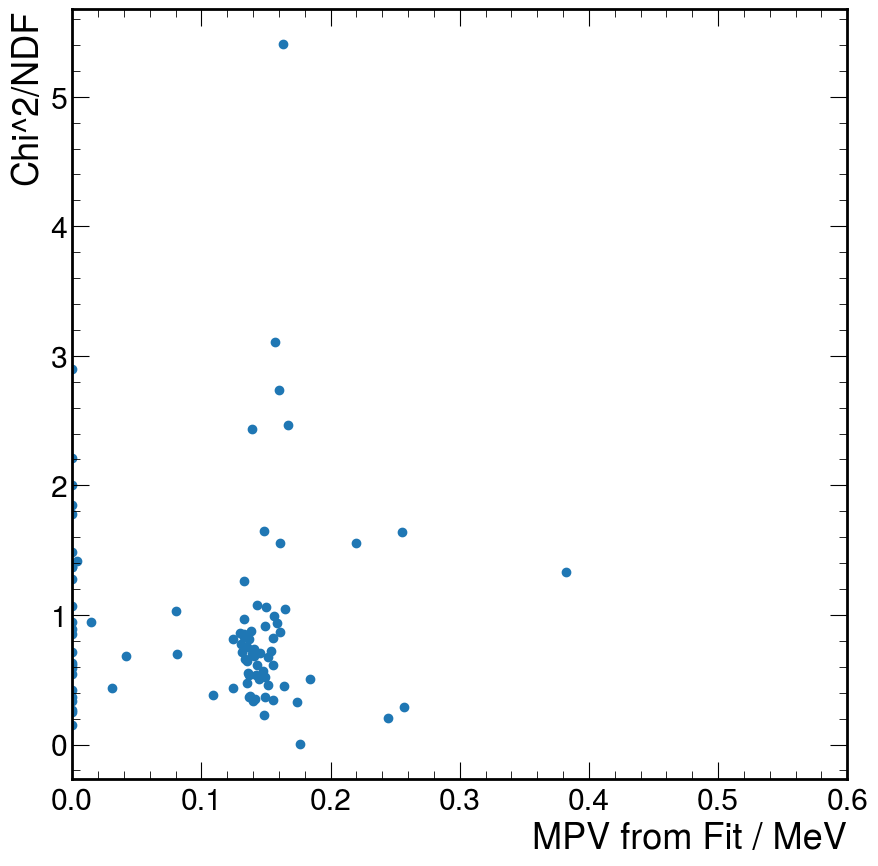

In [10]:
plt.scatter(stats.MPV,(stats.Chi2/stats.NDF))
plt.ylabel('Chi^2/NDF')
plt.xlabel('MPV from Fit / MeV')
plt.xlim(0,0.6)
#plt.xscale('log')
#plt.legend()
plt.savefig('chi2ndf.png')
#plt.axvline(0.13, color='gray')
#plt.axvline(0.26, color='gray')

plt.show()

In [ ]:
#get list of MPV = 0, do a function thhat pulls up the histogram for a any given cell

In [5]:
x = 'MAC2_cell_amplitude_l0_m0_u12_v12'

In [ ]:
(37 thousand e-h pairs / MIP) * (0.1602 fC / thousand e-h pairs) / (0.13 MeV / MIP) = 45.5954 fC / MeV

In [13]:
#print(u"\u00B1")
pm = u"\u00B1"
print (pm)

±


 FCN=39.5303 FROM HESSE     STATUS=OK             16 CALLS         277 TOTAL
                     EDM=2.03249e-07    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     7.10884e+02   5.03442e+01   2.12833e-02  -8.31196e-06
   2  MPV          1.48682e-01   1.98851e-03   1.02983e-06  -3.20435e-01
   3  Sigma        1.88471e-02   1.00071e-03   3.51322e-07  -1.03605e+00


Info in <TCanvas::Print>: png file plot2.png has been created


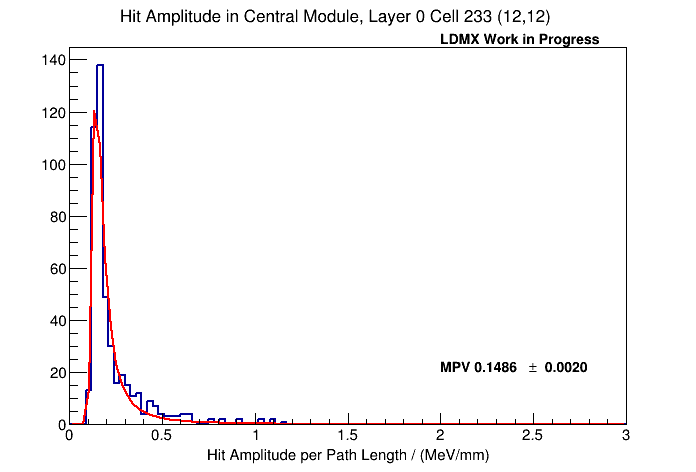

In [6]:
f = ROOT.TFile('hist-filtering-v2.root')
d = f.Get('MAC2')
c = ROOT.TCanvas()
fl = ROOT.TF1('seedparamslandau','landau')
fl.SetParameters(1,0.1,0.1)
fl.SetParLimits(1,0,5)
h = d.Get(x)
h.Draw()
fr = h.Fit(fl,'BSM').Get()
h.Draw()
c.Draw()
latex = ROOT.TLatex(2,20, "MPV 0.1486  #pm  0.0020")
latex1 = ROOT.TLatex(2,146, "LDMX Work in Progress")
latex1.SetTextSize(0.032)
latex.SetTextSize(0.032)
latex1.Draw()
latex.Draw()
c.Print("plot2.png")



 FCN=39.5303 FROM HESSE     STATUS=OK             16 CALLS         303 TOTAL
                     EDM=2.36731e-08    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     7.10889e+02   5.03398e+01   2.12777e-02   4.31436e-06
   2  MPV          6.77922e+00   9.06439e-02   3.98892e-05   1.97472e-03
   3  Sigma        8.59342e-01   4.56169e-02   1.60243e-05  -1.46881e-03


Info in <TCanvas::Print>: png file scaled.png has been created


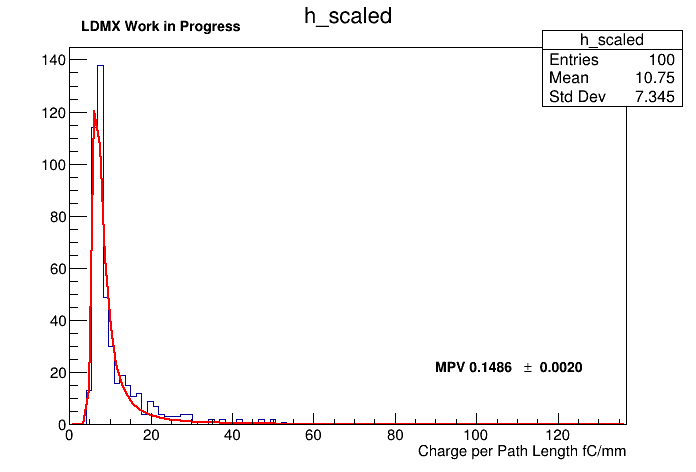

In [20]:
f = ROOT.TFile('hist-filtering-v2.root')
d = f.Get('MAC2')
h = d.Get(x)
# I want to transform the bins from 0->100 to be 0->1
# so I will be multiplying the xbins by 1/100
scale_factor = 45.5954

# the number of bins stays the same, we just multiply
# the lower limit and upper limit by our scale factor
nbins = h.GetNbinsX()
h_scaled = ROOT.TH1F(
    "h_scaled","h_scaled",
    nbins,
    h.GetBinLowEdge(1)*scale_factor,
    (h.GetBinLowEdge(nbins)+h.GetBinWidth(nbins))*scale_factor
)
#h_scaled.Sumw2()
# copy over the bin content and bin errors from the original histogram
# the bin indices are the same, we just are copying the content into
# a histogram that has different locations for the same bin indices
for i_bin in range(1,nbins+1):
    h_scaled.SetBinContent(i_bin, h.GetBinContent(i_bin))
    #h_scaled.SetBinError(i_bin, h.GetBinError(i_bin))

# now if I draw the scaled histogram, I get the same content
# but its 100 bins between 0 and 1
# NOTE: The "Entries" says 100 even though we actually have 10k entries.
#  I don't know how to fix this.
c = ROOT.TCanvas()
fl = ROOT.TF1('seedparamslandau','landau')
fl.SetParameters(45,0.45,0.45)
fl.SetParLimits(45,0,225)
h_scaled.Draw()
fr = h_scaled.Fit(fl,'BSM').Get()
h_scaled.GetXaxis().SetTitle("Charge per Path Length/ (fC/mm)")
h_scaled.Draw()
c.Draw()
latex = ROOT.TLatex(90,20, "MPV 0.1486  #pm  0.0020")
latex1 = ROOT.TLatex(3,151, "LDMX Work in Progress")
latex1.SetTextSize(0.032)
latex.SetTextSize(0.032)
latex1.Draw()
latex.Draw()
c.SaveAs("scaled.png")

 FCN=39.5303 FROM HESSE     STATUS=OK             16 CALLS         303 TOTAL
                     EDM=2.36731e-08    STRATEGY= 1      ERROR MATRIX ACCURATE 
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  Constant     7.10889e+02   5.03398e+01   2.12777e-02   4.31436e-06
   2  MPV          6.77922e+00   9.06439e-02   3.98892e-05   1.97472e-03
   3  Sigma        8.59342e-01   4.56169e-02   1.60243e-05  -1.46881e-03


Info in <TCanvas::Print>: png file scaled.png has been created
Info in <TCanvas::Print>: pdf file scaled.pdf has been created


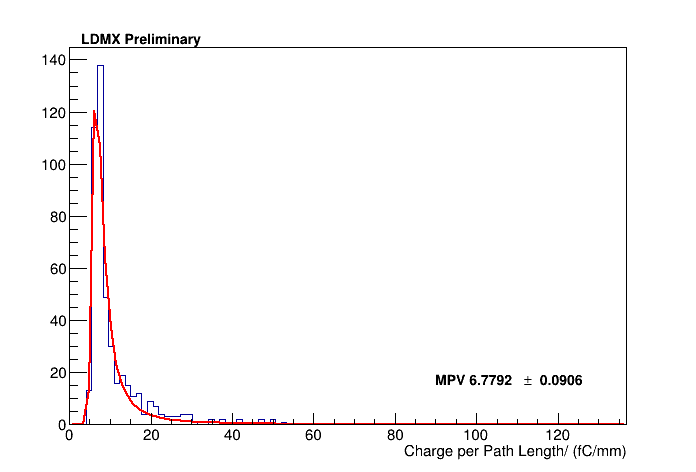

In [41]:

f = ROOT.TFile('hist-filtering-v2.root')
d = f.Get('MAC2')
h = d.Get(x)
# I want to transform the bins from 0->100 to be 0->1
# so I will be multiplying the xbins by 1/100
scale_factor = 45.5954

# the number of bins stays the same, we just multiply
# the lower limit and upper limit by our scale factor
nbins = h.GetNbinsX()
h_scaled = ROOT.TH1F(
    "h_scaled"," ",
    nbins,
    h.GetBinLowEdge(1)*scale_factor,
    (h.GetBinLowEdge(nbins)+h.GetBinWidth(nbins))*scale_factor
)
#h_scaled.Sumw2()
# copy over the bin content and bin errors from the original histogram
# the bin indices are the same, we just are copying the content into
# a histogram that has different locations for the same bin indices
for i_bin in range(1,nbins+1):
    h_scaled.SetBinContent(i_bin, h.GetBinContent(i_bin))
    #h_scaled.SetBinError(i_bin, h.GetBinError(i_bin))

# now if I draw the scaled histogram, I get the same content
# but its 100 bins between 0 and 1
# NOTE: The "Entries" says 100 even though we actually have 10k entries.
#  I don't know how to fix this.
c = ROOT.TCanvas()
fl = ROOT.TF1('seedparamslandau','landau')
fl.SetParameters(45,0.45,0.45)
fl.SetParLimits(45,0,225)
h_scaled.Draw()
fr = h_scaled.Fit(fl,'BSM').Get()
h_scaled.GetXaxis().SetTitle("Charge per Path Length/ (fC/mm)")
h_scaled.SetStats(stats=False)
h_scaled.Draw()
c.Draw()
latex = ROOT.TLatex(90,15, "MPV 6.7792  #pm  0.0906")
latex1 = ROOT.TLatex(3,146, "LDMX Preliminary")
latex1.SetTextSize(0.032)
latex.SetTextSize(0.032)
latex1.Draw()
latex.Draw()
c.SaveAs("scaled.png")
c.SaveAs("scaled.pdf")